# Accept-Reject Sampling

Demonstrations of the accept-reject algorithm implemented in `mcmc_algorithms.algorithms.accept_reject`. Each section proposes samples from an envelope distribution `r` and accepts them with probability `pi.pdf(x) / (M * r.pdf(x))`.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

from mcmc_algorithms.algorithms import accept_reject

FIGURES_DIR = Path("../figures")

## A custom, non-standard target density

`custom_target` is an unnormalized, multimodal density used purely to illustrate that the envelope only needs to dominate the target, not resemble it.

In [3]:
student = stats.t
normal = stats.norm
df = 1
uniform = stats.uniform


def custom_target(x):
    return np.exp(-x**2 / 2) * (np.sin(6 + x)**2 + 3 * np.cos(x)**2 * np.sin(4 * x)**2 + 1)


class DensityWrapper:
    """Adapts a plain density function to the r/pi.pdf interface accept_reject expects."""

    def __init__(self, pdf):
        self.pdf = pdf

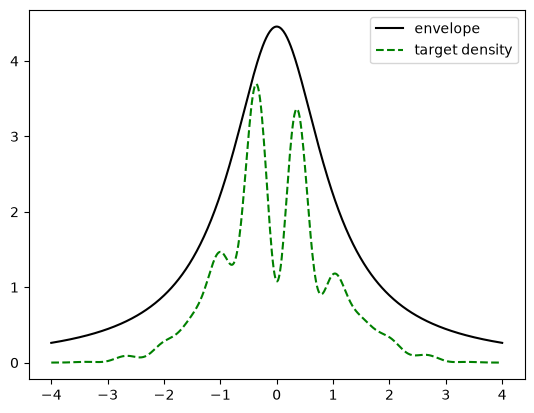

In [4]:
fig, ax = plt.subplots(1, 1)

x = np.linspace(-4, 4, 500)
ax.plot(x, 14 * student.pdf(x, df), 'k', label="envelope")
ax.plot(x, custom_target(x), 'g--', label="target density")
plt.legend()
plt.show()

## Uniform proposal, Normal target

In [5]:
r = stats.uniform(loc=-2, scale=4)
pi = stats.norm()
M = 2

accepted_xi = accept_reject(r, pi, M, steps=10000)
print(len(accepted_xi))

4738


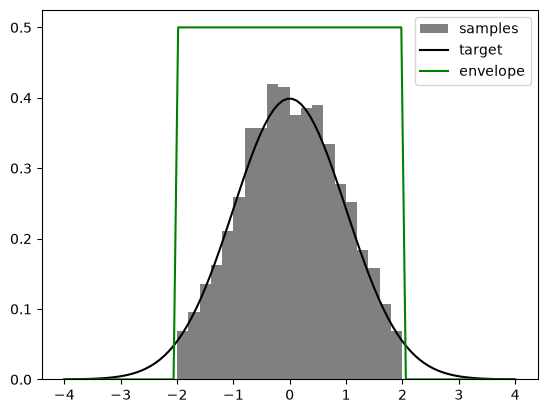

In [6]:
fig, ax = plt.subplots(1, 1)

x = np.linspace(-4, 4, 100)
plt.hist(accepted_xi, density=True, bins=20, label="samples", color='gray')
plt.plot(x, pi.pdf(x), 'k', label="target")
plt.plot(x, M * r.pdf(x), 'g', label="envelope")
plt.legend()

## Student-t proposal, Normal target

In [7]:
r = stats.t(df=1)
pi = stats.norm()
M = 2

accepted_xi = accept_reject(r, pi, M, steps=10000)
print(len(accepted_xi))

4911


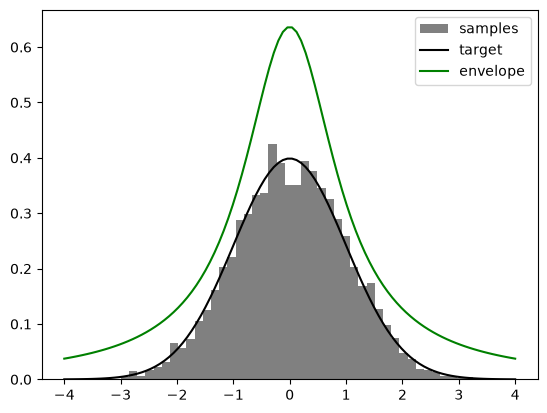

In [8]:
fig, ax = plt.subplots(1, 1)

x = np.linspace(-4, 4, 100)
plt.hist(accepted_xi, density=True, bins=50, label="samples", color='gray')
plt.plot(x, pi.pdf(x), 'k', label="target")
plt.plot(x, M * r.pdf(x), 'g', label="envelope")
plt.legend()
fig.savefig(FIGURES_DIR / "accept_reject_student_normal.png", dpi=150, bbox_inches="tight")

## Normal proposal, Student-t target

In [9]:
r = stats.norm()
pi = stats.t(df=1)
M = 1.5

accepted_xi = accept_reject(r, pi, M, steps=10000)
print(len(accepted_xi))

5090


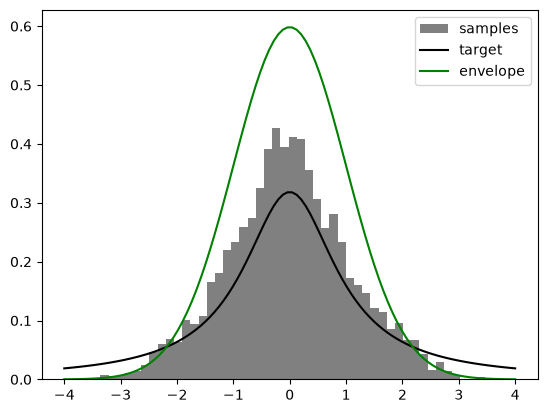

In [10]:
fig, ax = plt.subplots(1, 1)

x = np.linspace(-4, 4, 100)
plt.hist(accepted_xi, density=True, bins=50, label="samples", color='gray')
plt.plot(x, pi.pdf(x), 'k', label="target")
plt.plot(x, M * r.pdf(x), 'g', label="envelope")
plt.legend()

## Comparing all three envelopes against the custom target

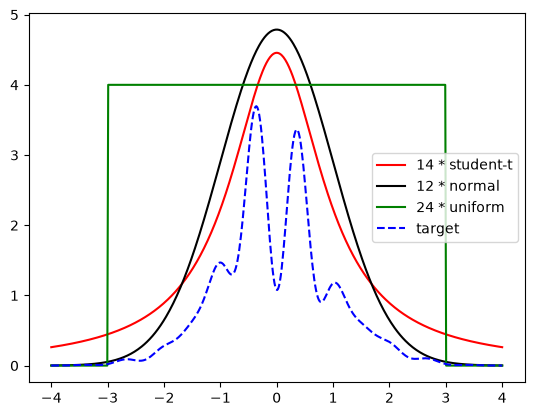

In [12]:
fig, ax = plt.subplots(1, 1)

x = np.linspace(-4, 4, 500)
ax.plot(x, 14 * student.pdf(x, df), 'r', label="14 * student-t")
ax.plot(x, 12 * normal.pdf(x), 'k', label="12 * normal")
ax.plot(x, 24 * uniform.pdf(x, loc=-3, scale=6), 'g', label="24 * uniform")
ax.plot(x, custom_target(x), 'b--', label="target")
plt.legend()
plt.show()

## Normal proposal, custom target

In [13]:
r = stats.norm()
pi = DensityWrapper(custom_target)
M = 12

accepted_xi = accept_reject(r, pi, M, steps=10000)
print(len(accepted_xi))

4750


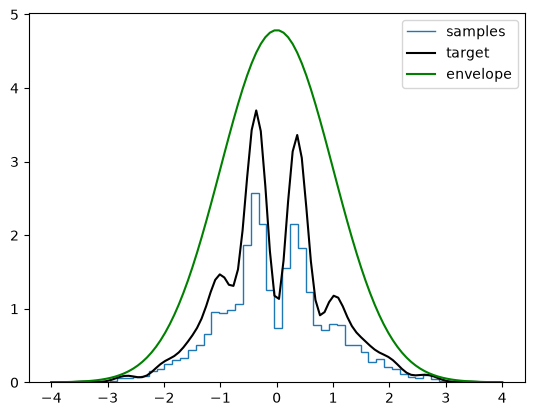

In [14]:
fig, ax_ = plt.subplots(1, 1)
x = np.linspace(-4, 4, 100)

counts, bins = np.histogram(accepted_xi, bins=50)
counts = counts / sum(counts) * np.diff(bins) * len(bins) * 4
plt.stairs(counts, bins, label="samples")
plt.plot(x, pi.pdf(x), 'k', label="target")
plt.plot(x, M * r.pdf(x), 'g', label="envelope")
plt.legend()